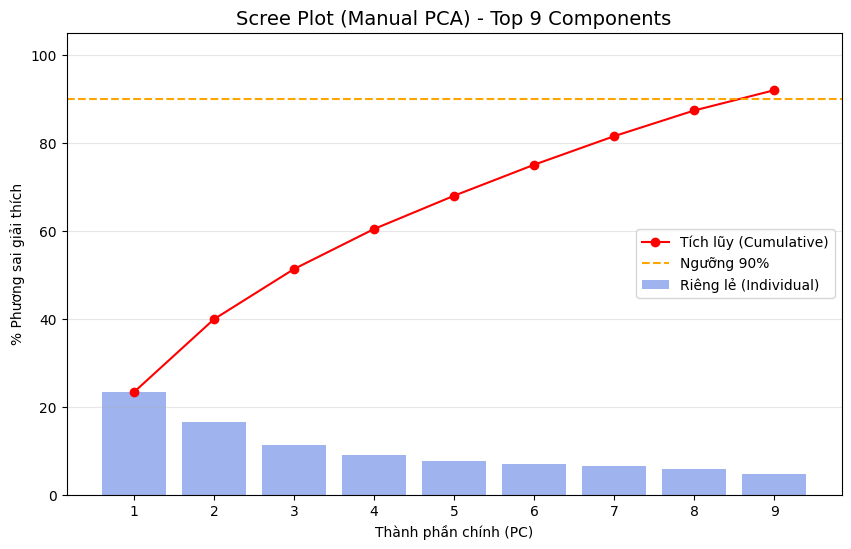


🔍 BÁO CÁO KẾT QUẢ PCA THỦ CÔNG:
- Tổng số biến ban đầu: 13
- Sau khi tính toán thủ công, tại PC thứ 9, phương sai tích lũy đạt 91.94%
- Kết luận: Việc chọn 9 PC là hoàn toàn hợp lý về mặt toán học.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    df = pd.read_csv('../clean/hanoi_aqi_cleaned.csv')
except:
    df = pd.read_csv('./clean/hanoi_aqi_cleaned.csv')

target_cols = ['co', 'no2', 'o3', 'pm10', 'pm25', 'so2', 'clouds', 
               'precipitation', 'pressure', 'relative_humidity', 
               'temperature', 'uv_index', 'wind_speed']

df.columns = df.columns.str.strip().str.lower()
cols_found = [c for c in target_cols if c in df.columns]

X = df[cols_found].apply(pd.to_numeric, errors='coerce').fillna(df[cols_found].median(numeric_only=True))
X_values = X.values

X_std = (X_values - np.mean(X_values, axis=0)) / (np.std(X_values, axis=0) + 1e-8)

cov_mat = np.cov(X_std.T)
cov_mat = np.nan_to_num(cov_mat)

eigen_vals, _ = np.linalg.eig(cov_mat)

sorted_indices = np.argsort(np.real(eigen_vals))[::-1]
sorted_eigen = np.real(eigen_vals)[sorted_indices]

exp_var = (sorted_eigen / np.sum(sorted_eigen)) * 100
cum_var = np.cumsum(exp_var)

n_components_to_show = 9 

plt.figure(figsize=(10, 6))

plt.bar(range(1, n_components_to_show + 1), exp_var[:n_components_to_show], 
        alpha=0.5, color='royalblue', label='Riêng lẻ (Individual)')

plt.plot(range(1, n_components_to_show + 1), cum_var[:n_components_to_show], 
         marker='o', color='red', label='Tích lũy (Cumulative)')

plt.axhline(y=90, color='orange', linestyle='--', label='Ngưỡng 90%')

plt.title(f'Scree Plot (Manual PCA) - Top {n_components_to_show} Components', fontsize=14)
plt.xlabel('Thành phần chính (PC)'); plt.ylabel('% Phương sai giải thích')
plt.xticks(range(1, n_components_to_show + 1))
plt.ylim(0, 105) 
plt.legend(loc='center right')
plt.grid(axis='y', alpha=0.3)
plt.show()

pc_90 = np.argmax(cum_var >= 90) + 1
print("\n" + "="*55)
print("🔍 BÁO CÁO KẾT QUẢ PCA THỦ CÔNG:")
print(f"- Tổng số biến ban đầu: {len(cols_found)}")
print(f"- Sau khi tính toán thủ công, tại PC thứ {pc_90}, phương sai tích lũy đạt {cum_var[pc_90-1]:.2f}%")
print(f"- Kết luận: Việc chọn {n_components_to_show} PC là hoàn toàn hợp lý về mặt toán học.")
print("="*55)